# Taller de IA — Parte 1: Ver dígitos escritos a mano

Este taller tiene **cuatro partes**. En todas la pregunta es la misma: *¿qué hay en esta imagen?*

- **Parte 1 (esta notebook):** la máquina **aprende** a leer dígitos a mano (Keras) y, al final, **ejecuta** esa misma red con OpenCV.
- **Parte 2** (`02_qr/codigo/02_taller_qr.ipynb`): visión en **software** — generar y leer un QR, y usar el texto en una mini-app (catálogo).
- **Parte 3** (`03_aruco/codigo/03_taller_aruco.ipynb`): visión en **robótica** — marcadores ArUco (ID + posición).
- **Parte 4** (`04_moda/codigo/04_taller_moda.ipynb`): **reto** de visión en moda (Fashion-MNIST + OpenCV).

Empieza aquí. OpenCV entra en el paso 8, con los dígitos que ya entrenaste. Después, la Parte 2 reutiliza `cv2` para QR.

## Dataset MNIST

70,000 imágenes de dígitos manuscritos (0–9):

- 60,000 para entrenar
- 10,000 para probar
- cada una es 28×28 píxeles en escala de grises

## Objetivo de esta parte

Una red neuronal simple que clasifique más del **95%** de los dígitos de prueba, y ver esa misma red correr en OpenCV.


## Paso 1: Preparar las herramientas

**Tarea**: Importar TensorFlow/Keras, NumPy y Matplotlib.

**Enfoque**: Tres librerías, cada una con un rol:

- **TensorFlow / Keras** — definir, entrenar y evaluar la red
- **NumPy** — arreglos (las imágenes son matrices de números)
- **Matplotlib** — ver dígitos, curvas de entrenamiento y predicciones


**Código**:

In [1]:
%matplotlib inline
# TensorFlow/Keras: modelo. NumPy: arreglos. Matplotlib: figuras en el notebook.
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Semillas para que épocas y figuras se parezcan entre corridas.
# En CPU, TensorFlow aún puede variar un poco (ops no deterministas).
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow versión:", tf.__version__)
print("Librerías importadas correctamente!")


TensorFlow versión: 2.20.0
Librerías importadas correctamente!


**Resultado**: TensorFlow 2.20.0 y el resto de librerías cargaron bien. El entorno de la Parte 1 está listo.

Siguiente: cargar las imágenes con las que va a aprender la red.


## Paso 2: Cargar MNIST

**Tarea**: Descargar el dataset y comprobar formas y rango de píxeles.

**Enfoque**: Keras incluye MNIST. La primera vez se guarda en `~/.keras/datasets/`.

- **Entrenamiento** (60,000) — ejemplos para ajustar la red
- **Prueba** (10,000) — imágenes que la red no ve durante el entrenamiento; sirven para medir si *generalizó*

Cada imagen es 28×28, con píxeles de 0 (negro) a 255 (blanco).


**Código**:

In [2]:
# MNIST viene con Keras; la primera vez se descarga a ~/.keras/datasets/
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# x_*: (N, 28, 28) uint8 en 0–255. y_*: (N,) enteros 0–9.

print("Datos de entrenamiento:")
print(f"   - Imágenes: {x_train.shape}")
print(f"   - Etiquetas: {y_train.shape}")
print("\nDatos de prueba:")
print(f"   - Imágenes: {x_test.shape}")
print(f"   - Etiquetas: {y_test.shape}")

print(f"\nCada imagen es de {x_train.shape[1]}x{x_train.shape[2]} píxeles")
print(f"Valores de píxeles van de {x_train.min()} a {x_train.max()}")


Datos de entrenamiento:
   - Imágenes: (60000, 28, 28)
   - Etiquetas: (60000,)

Datos de prueba:
   - Imágenes: (10000, 28, 28)
   - Etiquetas: (10000,)

Cada imagen es de 28x28 píxeles


Valores de píxeles van de 0 a 255


**Resultado**: 60,000 imágenes de entrenamiento y 10,000 de prueba, forma `(N, 28, 28)`, etiquetas 0–9, píxeles 0–255.

Siguiente: mirar algunos ejemplos antes de transformar nada.


### Visualización de ejemplos

**Tarea**: Mostrar 16 dígitos del conjunto de entrenamiento.

**Enfoque**: La escritura varía (grosor, inclinación, centrado). La red tendrá que encontrar lo que esas variantes tienen en común.

**Código**:


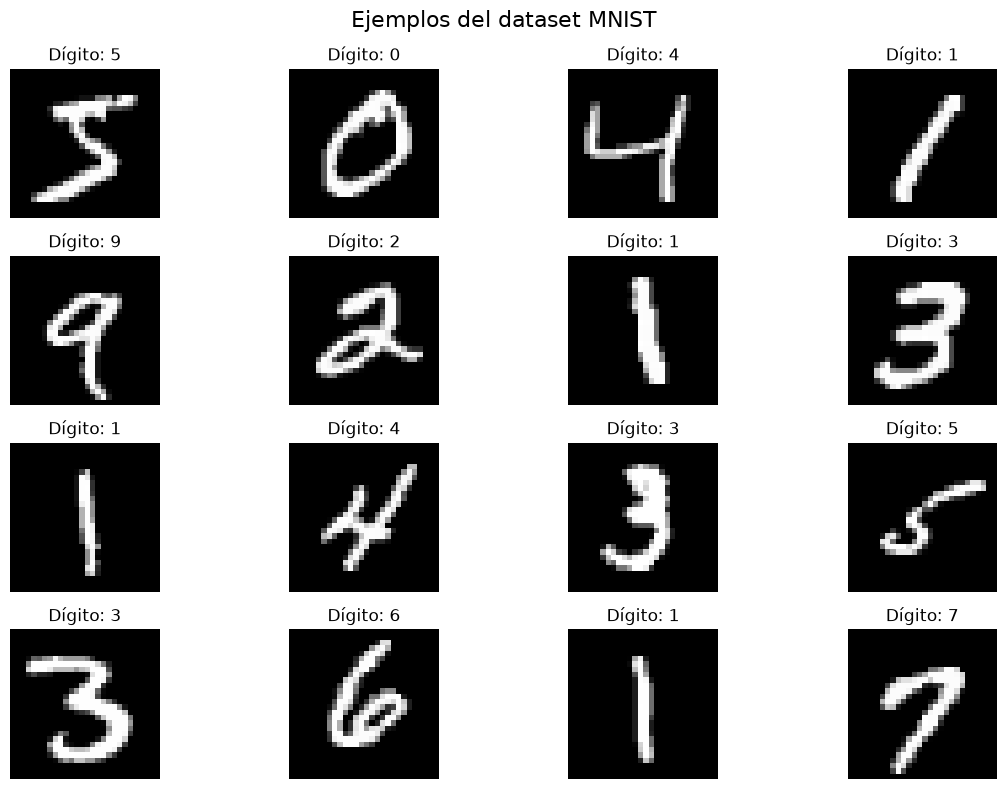

In [3]:
# 16 primeras imágenes de entrenamiento (no están barajadas aquí).
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Dígito: {y_train[i]}')
    plt.axis('off')

plt.suptitle('Ejemplos del dataset MNIST', fontsize=16)
plt.tight_layout()
plt.show()


**Resultado**: 16 dígitos distintos a simple vista. Esa diversidad es el problema: no hay un único “aspecto” del 4 o del 8.

Siguiente: poner los datos en el formato que la red espera.


## Paso 3: Preparar los datos

**Tarea**: Normalizar píxeles a [0, 1] y aplanar cada imagen a un vector de 784 valores.

**Enfoque**:

- **Normalizar** (dividir entre 255) — las capas densas aprenden más estable con entradas pequeñas
- **Aplanar** (28×28 → 784) — esta red no ve la imagen como una cuadrícula; recibe un vector. Dejamos `x_train` / `x_test` en 2D para poder dibujarlas después


**Código**:

In [4]:
# Las capas densas convergen mejor con entradas en [0, 1] que en [0, 255].
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Dense espera un vector: 28×28 = 784. Dejamos x_train/x_test en 2D para dibujar.
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print("Datos preparados:")
print(f"   - Forma de datos de entrenamiento: {x_train_flat.shape}")
print(f"   - Forma de datos de prueba: {x_test_flat.shape}")
print(f"   - Rango de valores: {x_train_flat.min():.1f} - {x_train_flat.max():.1f}")
print(f"   - Número de clases (dígitos): {len(np.unique(y_train))}")


Datos preparados:
   - Forma de datos de entrenamiento: (60000, 784)
   - Forma de datos de prueba: (10000, 784)
   - Rango de valores: 0.0 - 1.0
   - Número de clases (dígitos): 10


**Resultado**: Entrenamiento `(60000, 784)`, prueba `(10000, 784)`, valores en [0.0, 1.0], 10 clases.

Siguiente: armar la red que va a leer esos vectores.


## Paso 4: Diseñar la red

**Tarea**: Un MLP que clasifique cada vector de 784 píxeles en un dígito 0–9.

**Enfoque**:

- **Entrada** — `Input(shape=(784,))`, un vector por imagen
- **Oculta** — 128 neuronas ReLU: aquí se aprenden los patrones
- **Dropout 20%** — apaga neuronas al azar *solo al entrenar*, para no memorizar
- **Salida** — 10 neuronas softmax: una probabilidad por dígito, suman 1

Al compilar: optimizador **Adam**, pérdida **sparse_categorical_crossentropy** (la etiqueta es un entero 0–9, no un one-hot) y métrica **accuracy**.


**Código**:

In [5]:
# MLP: 784 → 128 ReLU → dropout 20% → 10 softmax (P(dígito)).
model = keras.Sequential([
    keras.Input(shape=(784,)),  # declara la forma; no añade parámetros
    keras.layers.Dense(128, activation='relu'),  # capa que aprende patrones
    keras.layers.Dropout(0.2),  # apaga 20% de neuronas solo al entrenar
    keras.layers.Dense(10, activation='softmax'),  # 10 clases, probs suman 1
])

# sparse_categorical_crossentropy: y es un entero 0–9, no un vector one-hot.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

print("Arquitectura de la Red Neuronal:")
model.summary()


Arquitectura de la Red Neuronal:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

**Resultado**: 101,770 parámetros entrenables (100,480 + 1,290). Dropout no añade parámetros.

Siguiente: mostrar esas 60,000 imágenes a la red, varias veces.


## Paso 5: Entrenar

**Tarea**: Ajustar los pesos durante 5 épocas.

**Enfoque**:

- **Época** — una pasada por los datos de entrenamiento
- **Lote de 128** — no una imagen a la vez: más estable y más rápido
- **Validación 10%** — Keras reserva el último 10% de `x_train_flat` y no lo usa para actualizar pesos; sirve para ver si está memorizando

En cada lote: predecir → medir error → Adam mueve los pesos un poco.


**Código**:

In [6]:
# Una época = una pasada por el 90% de entrenamiento (el 10% es validación).
print("Comenzando el entrenamiento...")
print("Verás cómo mejora la precisión en cada época\n")

history = model.fit(
    x_train_flat, y_train,
    epochs=5,
    batch_size=128,          # 128 imágenes por paso de gradiente
    validation_split=0.1,    # último 10% de x_train_flat; Keras no lo baraja
    verbose=2,               # una línea de métricas por época
)

print("\nEntrenamiento completado!")


Comenzando el entrenamiento...
Verás cómo mejora la precisión en cada época

Epoch 1/5
422/422 - 3s - 6ms/step - accuracy: 0.8799 - loss: 0.4266 - val_accuracy: 0.9548 - val_loss: 0.1704
Epoch 2/5
422/422 - 2s - 4ms/step - accuracy: 0.9405 - loss: 0.2040 - val_accuracy: 0.9628 - val_loss: 0.1253
Epoch 3/5
422/422 - 1s - 3ms/step - accuracy: 0.9551 - loss: 0.1548 - val_accuracy: 0.9682 - val_loss: 0.1048
Epoch 4/5
422/422 - 1s - 3ms/step - accuracy: 0.9618 - loss: 0.1276 - val_accuracy: 0.9713 - val_loss: 0.0930
Epoch 5/5
422/422 - 2s - 4ms/step - accuracy: 0.9687 - loss: 0.1047 - val_accuracy: 0.9732 - val_loss: 0.0867

Entrenamiento completado!


**Resultado**: El entrenamiento terminó. Precisión de entrenamiento 87.99% → 96.87%; validación 95.48% → 97.32%. La pérdida baja en ambos (train 0.4266 → 0.1047, val 0.1704 → 0.0867). Validación por encima de entrenamiento es señal de que Dropout está haciendo su trabajo.

Siguiente: medir con las 10,000 imágenes que *nunca* vio.


## Paso 6: Evaluar en prueba

**Tarea**: Calcular precisión y pérdida en el conjunto de prueba.

**Enfoque**: Si solo midieras entrenamiento, podrías estar viendo memorización. Las 10,000 de prueba son el dato que importa. Objetivo de esta parte: **>95%**.


**Código**:

In [7]:
# Conjunto de prueba: 10,000 imágenes que el modelo no usó en fit().
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)

print("Resultados finales:")
print(f"   Precisión en datos de prueba: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Pérdida en datos de prueba: {test_loss:.4f}")

if test_accuracy > 0.95:
    print("Excelente! La red tiene más del 95% de precisión")
elif test_accuracy > 0.90:
    print("Muy bien! La red tiene más del 90% de precisión")
else:
    print("La red necesita más entrenamiento")


Resultados finales:
   Precisión en datos de prueba: 0.9708 (97.08%)
   Pérdida en datos de prueba: 0.0948
Excelente! La red tiene más del 95% de precisión


**Resultado**: **97.08%** de precisión (9,708 / 10,000) y pérdida 0.0948. Superamos el 95%. La red no solo memorizó: acierta en dígitos nuevos.

Siguiente: ver *cómo* llegó ahí (curvas) y luego predicciones concretas.


### Curvas de aprendizaje

**Tarea**: Graficar precisión y pérdida de entrenamiento vs validación en las 5 épocas.

**Enfoque**: Si las dos curvas se pegan, el aprendizaje es sano. Si entrenamiento sube y validación se cae, hay sobreajuste.

**Código**:


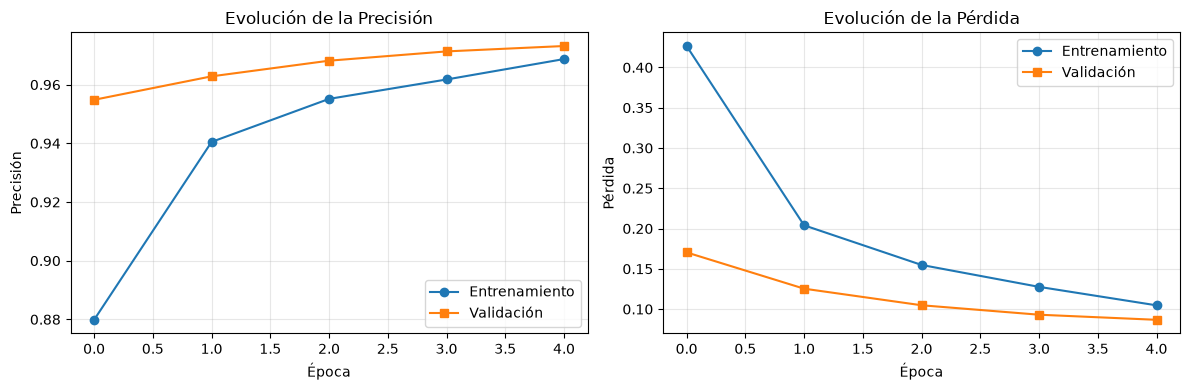

In [8]:
# history.history guarda accuracy/loss de train y val en cada época.
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento', marker='o')
plt.plot(history.history['val_accuracy'], label='Validación', marker='s')
plt.title('Evolución de la Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento', marker='o')
plt.plot(history.history['val_loss'], label='Validación', marker='s')
plt.title('Evolución de la Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Resultado**: Precisión de entrenamiento ~88% → ~97%; validación parte cerca de 95% y termina ~98%. La pérdida de validación baja ~0.17 → ~0.08. Las curvas van juntas: no hay sobreajuste evidente.

Siguiente: 16 predicciones con imagen, etiqueta, predicción y confianza.


## Paso 7: Ver predicciones

**Tarea**: Clasificar las primeras 16 imágenes de prueba y pintar acierto/error.

**Enfoque**: Softmax da 10 probabilidades; nos quedamos con el dígito de mayor probabilidad (confianza = ese máximo). Verde = acierto, rojo = error. Una muestra de 16 **no** sustituye al 97.23% del paso 6; solo sirve para mirar casos.


**Código**:

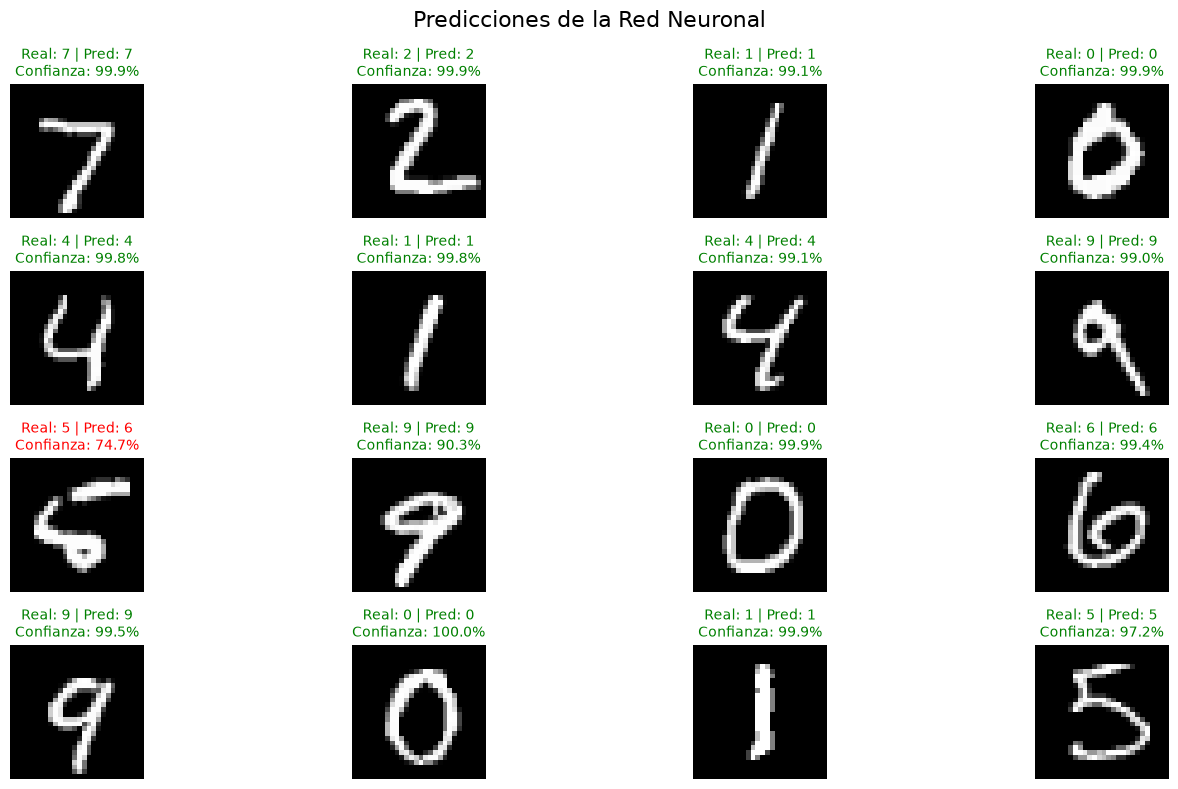

Aciertos: 15/16 (93.8%)
Errores: 1/16 (6.2%)


In [9]:
# Softmax → vector de 10 probs; argmax es el dígito predicho.
predictions = model.predict(x_test_flat[:16], verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(15, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_test[i], cmap='gray')
    # Verde = acierto, rojo = error (la muestra es pequeña: 16 de 10,000).
    color = 'green' if predicted_classes[i] == y_test[i] else 'red'
    confidence = np.max(predictions[i]) * 100
    plt.title(
        f'Real: {y_test[i]} | Pred: {predicted_classes[i]}\nConfianza: {confidence:.1f}%',
        color=color,
        fontsize=10,
    )
    plt.axis('off')

plt.suptitle('Predicciones de la Red Neuronal', fontsize=16)
plt.tight_layout()
plt.show()

correct = sum(predicted_classes == y_test[:16])
print(f"Aciertos: {correct}/16 ({correct/16*100:.1f}%)")
print(f"Errores: {16-correct}/16 ({(16-correct)/16*100:.1f}%)")


**Resultado**: En esta corrida, 15/16 aciertos en la muestra (93.8%). El número que cuenta sigue siendo el del conjunto completo: **97.08%**.

Con esto cierra el objetivo de la Parte 1: una red que *aprendió* a ver dígitos. En la Parte 2 no vamos a entrenar otra: vamos a leer etiquetas que el entorno ya trae diseñadas.


## Paso 8: El mismo modelo, ahora con OpenCV

**Tarea**: Exportar la red entrenada a TFLite y clasificar las mismas 16 imágenes del paso 7 con `cv2.dnn`.

**Enfoque**: OpenCV es la librería de visión que usan apps (Parte 2) y robots (Parte 3). `cv2.dnn` **no entrena**: corre un modelo que ya existe.

El puente es Keras → TFLite (formato compacto, viene con TensorFlow) → `cv2.dnn.readNetFromTFLite`. Es la red del paso 4, otro motor. Si las predicciones coinciden, el puente está bien: a partir de aquí `cv2` ya está en el taller.


**Código**:

In [10]:
import io
import os
import tempfile
import contextlib
import cv2

print("OpenCV versión:", cv2.__version__)

# Keras → TFLite (archivo temporal; no se versiona en el repo).
converter = tf.lite.TFLiteConverter.from_keras_model(model)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    tflite_bytes = converter.convert()

tflite_path = os.path.join(tempfile.gettempdir(), "mnist_mlp.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_bytes)

net = cv2.dnn.readNetFromTFLite(tflite_path)
print(f"Red cargada en cv2.dnn ({len(tflite_bytes)} bytes TFLite)")

# Las mismas 16 imágenes del paso 7.
muestra = x_test_flat[:16].astype("float32")
keras_clases = np.argmax(model.predict(muestra, verbose=0), axis=1)

net.setInput(muestra)
dnn_probs = net.forward()
dnn_clases = np.argmax(dnn_probs, axis=1)

print("i  | real | Keras | OpenCV | ¿igual?")
print("---+------+-------+--------+--------")
iguales = 0
for i in range(16):
    ok = int(dnn_clases[i] == keras_clases[i])
    iguales += ok
    print(
        f"{i:2d} |  {int(y_test[i])}   |   {int(keras_clases[i])}   |   "
        f"{int(dnn_clases[i])}    | {'sí' if ok else 'NO'}"
    )
print(f"\nCoincidencias Keras vs OpenCV: {iguales}/16")


OpenCV versión: 5.0.0


INFO:tensorflow:Assets written to: C:\Users\julih\AppData\Local\Temp\tmp3c9_masg\assets


Red cargada en cv2.dnn (408804 bytes TFLite)
i  | real | Keras | OpenCV | ¿igual?
---+------+-------+--------+--------
 0 |  7   |   7   |   7    | sí
 1 |  2   |   2   |   2    | sí
 2 |  1   |   1   |   1    | sí
 3 |  0   |   0   |   0    | sí
 4 |  4   |   4   |   4    | sí
 5 |  1   |   1   |   1    | sí
 6 |  4   |   4   |   4    | sí
 7 |  9   |   9   |   9    | sí
 8 |  5   |   6   |   6    | sí
 9 |  9   |   9   |   9    | sí
10 |  0   |   0   |   0    | sí
11 |  6   |   6   |   6    | sí
12 |  9   |   9   |   9    | sí
13 |  0   |   0   |   0    | sí
14 |  1   |   1   |   1    | sí
15 |  5   |   5   |   5    | sí

Coincidencias Keras vs OpenCV: 16/16


**Resultado**: OpenCV 5.0.0 carga la red (TFLite) y clasifica las mismas 16 imágenes. **16/16 coincidencias** con Keras, incluso en el error compartido (índice 8: un 5 que ambos leen como 6). Mismo modelo, otro motor.

Siguiente: Parte 2 (`02_qr/codigo/02_taller_qr.ipynb`). Ya tienes `cv2`; ahí no hay red que entrenar: el QR **es** el texto.


## Cierre de la Parte 1

La máquina **aprendió** a ver dígitos (Keras) y **los volvió a leer** con OpenCV (`cv2.dnn`).

### Qué aprendimos
1. Cargar y mirar MNIST
2. Normalizar y aplanar
3. Armar un MLP (ReLU, dropout, softmax)
4. Entrenar con épocas, lotes y validación
5. Evaluar en prueba
6. Leer predicciones y confianza
7. Exportar a TFLite y ejecutar el mismo modelo con OpenCV

### Siguiente: Parte 2

Abre `02_qr/codigo/02_taller_qr.ipynb`. Misma librería (`cv2`), otra tarea: generar y leer un **código QR** y usar el texto en una mini-app (SKU, catálogo). Eso es visión aplicada a desarrollo de software.

La Parte 3 (`03_aruco/codigo/03_taller_aruco.ipynb`) son etiquetas para robots. El taller cierra con la Parte 4 (`04_moda/codigo/04_taller_moda.ipynb`): un reto de prendas con OpenCV.

### Extra (opcional)

La celda de abajo inspecciona un dígito del conjunto de prueba, con las 10 probabilidades.


## Extra: un dígito a dígito

**Tarea**: Llamar `probar_digito(indice)` con cualquier índice 0–9999.

**Enfoque**: El modelo espera un *lote* de forma `(1, 784)`. La barra de la derecha es el vector softmax: la más alta es la predicción.

**Código**:


Puedes cambiar el número dentro de los paréntesis para probar diferentes dígitos:
   probar_digito(0)   # Prueba el primer dígito
   probar_digito(100) # Prueba el dígito en posición 100
   probar_digito(500) # Prueba el dígito en posición 500

Intenta con diferentes números!


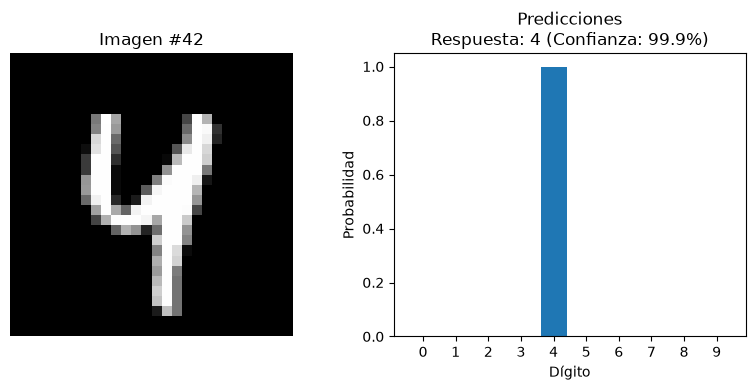

Imagen #42:
   Dígito real: 4
   Predicción: 4
   Confianza: 99.9%
   Correcto!


In [11]:
def probar_digito(indice=0):
    """Muestra una imagen de prueba, el dígito predicho y las 10 probabilidades.

    Parameters
    ----------
    indice : int
        Posición en `x_test` / `y_test` (0 … 9999).
    """
    imagen = x_test[indice]
    # El modelo espera un lote: (1, 784), no un vector suelto (784,).
    imagen_flat = x_test_flat[indice:indice + 1]

    prediccion = model.predict(imagen_flat, verbose=0)
    clase_predicha = np.argmax(prediccion)
    confianza = np.max(prediccion) * 100

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(imagen, cmap='gray')
    plt.title(f'Imagen #{indice}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.bar(range(10), prediccion[0])
    plt.title(f'Predicciones\nRespuesta: {clase_predicha} (Confianza: {confianza:.1f}%)')
    plt.xlabel('Dígito')
    plt.ylabel('Probabilidad')
    plt.xticks(range(10))

    plt.tight_layout()
    plt.show()

    print(f"Imagen #{indice}:")
    print(f"   Dígito real: {y_test[indice]}")
    print(f"   Predicción: {clase_predicha}")
    print(f"   Confianza: {confianza:.1f}%")

    if clase_predicha == y_test[indice]:
        print("   Correcto!")
    else:
        print("   Incorrecto")


print("Puedes cambiar el número dentro de los paréntesis para probar diferentes dígitos:")
print("   probar_digito(0)   # Prueba el primer dígito")
print("   probar_digito(100) # Prueba el dígito en posición 100")
print("   probar_digito(500) # Prueba el dígito en posición 500")
print("\nIntenta con diferentes números!")

probar_digito(42)
